# Ex. No: 12
# Face Detection with Haar Cascades

**Name :** DEEPIKA P **Reg. No :** 212223240024   **Slot No :** 26OD1143

**Note: This is face *detection* NOT face *recognition*. We are only detecting if a face is in an image, not who the face actually is. That requires deep learning.**

## 1) Load and Display Images

- Step 1: Import necessary packages: numpy, cv2, matplotlib.pyplot
- Step 2: Load grayscale images using cv2.imread() with flag 0
- Step 3: Display images using plt.imshow() with cmap='gray'

In [2]:
import numpy as np
import cv2 
import matplotlib.pyplot as plt
%matplotlib inline

## Images

In [3]:
model = cv2.imread('czsadew-1.png.png', 0)
withglass = cv2.imread('Hero-1di.png.png', 0)
group = cv2.imread('group_sec.png.png', 0)

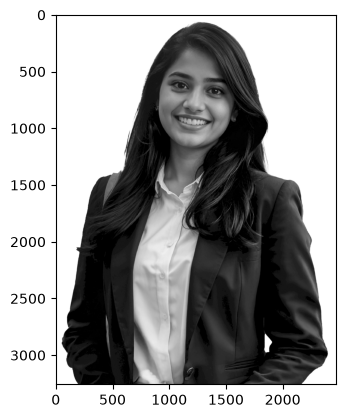

In [4]:
plt.imshow(model, cmap='gray')
plt.show()

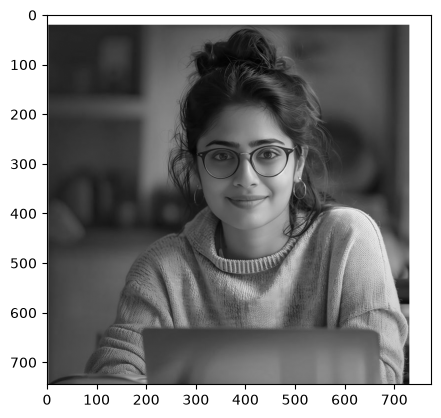

In [5]:
plt.imshow(withglass,cmap='gray')

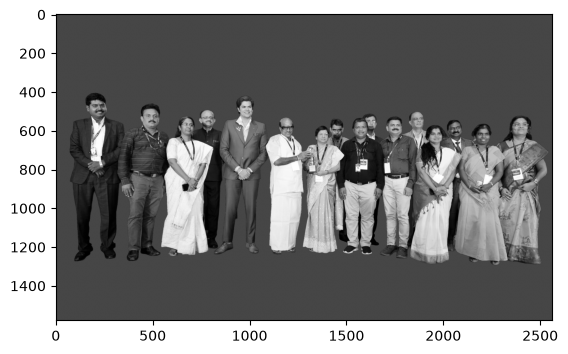

In [6]:
plt.imshow(group,cmap='gray')
plt.show()

## II) Load Haar Cascade Classifiers

- Step 1: Load face and eye cascade XML files

## Face Detection

In [7]:
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

## III) Perform Face Detection in Images

- Step 1: Define a function detect_face() that copies the input image
- Step 2: Use face_cascade.detectMultiScale() to detect faces
- Step 3: Draw white rectangles around detected faces with thickness 10
- Step 4: Return the processed image with rectangles

In [8]:
def detect_face(img):
    
  
    face_img = img.copy()
  
    face_rects = face_cascade.detectMultiScale(face_img) 
    
    for (x,y,w,h) in face_rects: 
        cv2.rectangle(face_img, (x,y), (x+w,y+h), (255,255,255), 10) 
        
    return face_img

In [9]:
result = detect_face(withglass)

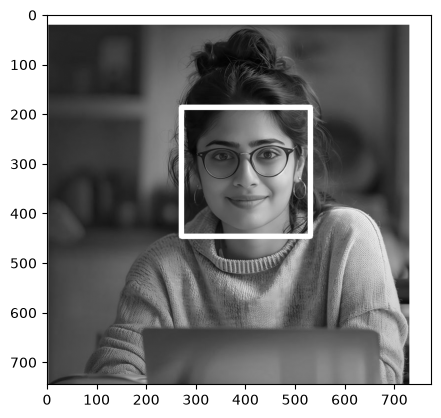

In [10]:
plt.imshow(result,cmap='gray')

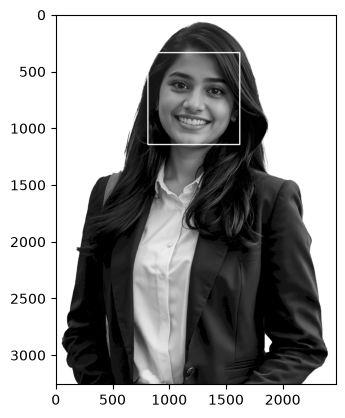

In [11]:
result = detect_face(model)
plt.imshow(result,cmap='gray')

In [ ]:

# Gets errors!
result = detect_face(group)
plt.imshow(result,cmap='gray')

In [13]:
def adj_detect_face(img):
    
    face_img = img.copy()
  
    face_rects = face_cascade.detectMultiScale(face_img,scaleFactor=1.2, minNeighbors=5) 
    
    for (x,y,w,h) in face_rects: 
        cv2.rectangle(face_img, (x,y), (x+w,y+h), (255,255,255), 10) 
        
    return face_img

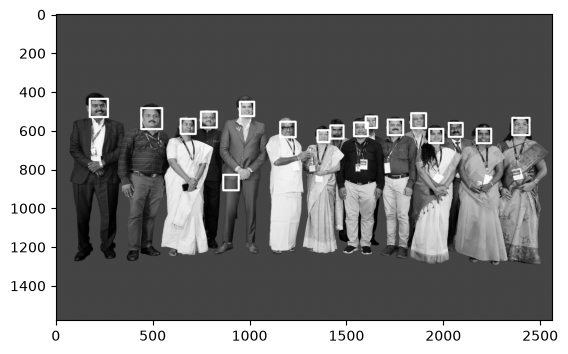

In [14]:
# Doesn't detect the side face.
result = adj_detect_face(group)
plt.imshow(result,cmap='gray')

## IV) Perform Eye Detection in Images & Display Detection Results on Images

- Step 1: Define a function detect_eyes() that copies the input image
- Step 2: Use eye_cascade.detectMultiScale() to detect eyes
- Step 3: Draw white rectangles around detected eyes with thickness 10
- Step 4: Return the processed image with rectangles
- Step 5: Call detect_face() or detect_eyes() on loaded images
- Step 6: Use plt.imshow() with cmap='gray' to display images with detected regions highlighted

In [15]:
eye_cascade = cv2.CascadeClassifier('haarcascade_eye.xml')

In [16]:
def detect_eyes(img):
    
    face_img = img.copy()
  
    eyes = eye_cascade.detectMultiScale(face_img) 
    
    
    for (x,y,w,h) in eyes: 
        cv2.rectangle(face_img, (x,y), (x+w,y+h), (255,255,255), 10) 
        
    return face_img

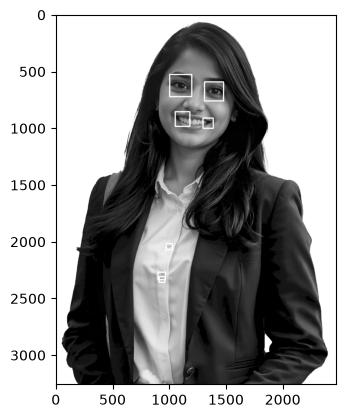

In [17]:
result = detect_eyes(model)
plt.imshow(result,cmap='gray')
plt.show()

In [18]:
eyes = eye_cascade.detectMultiScale(withglass) 

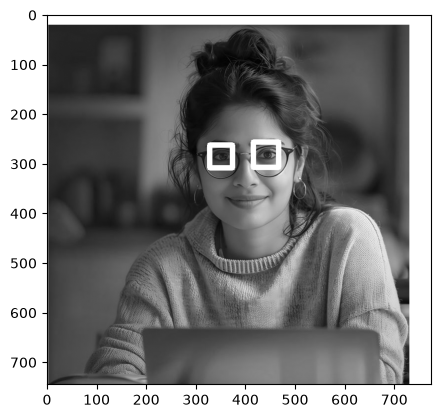

In [19]:
# White around the pupils is not distinct enough to detect Denis' eyes here!
result = detect_eyes(withglass)
plt.imshow(result,cmap='gray')
plt.show()

## VI) Perform Face Detection on Real-Time Webcam Video

- Step 1: Capture video from webcam using cv2.VideoCapture(0)
- Step 2: Loop to continuously read frames from webcam
- Step 3: Apply detect_face() function on each frame
- Step 4: Display the video frame with rectangles around detected faces
- Step 5: Exit loop and close windows when ESC key (key code 27) is pressed
- Step 6: Release video capture and destroy all OpenCV windows

In [6]:
import cv2
import matplotlib.pyplot as plt

In [8]:
def detect_face(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5
    )

    for (x, y, w, h) in faces:
        cv2.rectangle(
            frame,
            (x, y),
            (x + w, y + h),
            (255, 0, 0),
            2
        )

    return frame